In [1]:
import torch
import matplotlib.pyplot as plt
import os
import numpy as np

In [2]:
fno1d_numerical_w_sg_path = '/raid/work/sandbox/RealPDEBench/models/fno1d/fno1d_cylinder_eval/2026-07-09_15-59-08/'
fno1d_real_w_sg_path = '/raid/work/sandbox/RealPDEBench/models/fno1d/fno1d_cylinder_eval/2026-07-09_15-59-08'
fno1d_finetuned_w_sg_path = '/raid/work/sandbox/RealPDEBench/models/fno1d/fno1d_cylinder_eval/2026-07-09_15-59-08'

fno1d_real_wo_sg_path = '/raid/work/sandbox/RealPDEBench/models/fno1d/fno1d_cylinder_eval/2026-07-09_15-59-08'
fno1d_numerical_wo_sg_path = '/raid/work/sandbox/RealPDEBench/models/fno1d/fno1d_cylinder_eval/2026-07-09_15-59-07'

In [3]:
fno1d_numerical_w_sg_trajectories = torch.load(os.path.join(fno1d_numerical_w_sg_path, 'test_trajectories.pt'))
fno1d_real_w_sg_trajectories = torch.load(os.path.join(fno1d_real_w_sg_path, 'test_trajectories.pt'))
fno1d_finetuned_w_sg_trajectories = torch.load(os.path.join(fno1d_finetuned_w_sg_path, 'test_trajectories.pt'))

fno1d_real_wo_sg_trajectories = torch.load(os.path.join(fno1d_real_wo_sg_path, 'test_trajectories.pt'))
fno1d_numerical_wo_sg_trajectories = torch.load(os.path.join(fno1d_numerical_wo_sg_path, 'test_trajectories.pt'))

## Plot error between autoregressive and ground truth trajectories

In [4]:
def calculate_relative_loss(err, target=None, reduction="sum"):
    batch_size = err.shape[0]
    temp_size = err.shape[1]
    if isinstance(err, torch.Tensor):
        err_norm = torch.norm(err.reshape(batch_size, temp_size, -1), p=2, dim=2)
        if target is None:
            target_norm = 1.0
        else:
            target_norm = torch.norm(target.reshape(batch_size, temp_size,-1), p=2, dim=2)
        if reduction is None:
            return err_norm / target_norm
        elif reduction == "sum":
            return torch.sum(err_norm / target_norm, dim=0)
        else:
            return torch.mean(err_norm / target_norm, dim=0)
    else:
        err_norm = np.linalg.norm(err.reshape(batch_size, -1), ord=2, axis=1)
        if target is None:
            target_norm = 1.0
        else:
            target_norm = np.linalg.norm(target.reshape(batch_size, -1), ord=2, axis=1)
        if reduction is None:
            return err_norm / target_norm
        elif reduction == "sum":
            return np.sum(err_norm / target_norm)
        else:
            return np.mean(err_norm / target_norm)

In [5]:
fno1d_numerical_w_sg_rel_error = calculate_relative_loss(fno1d_numerical_w_sg_trajectories['pred'] - fno1d_numerical_w_sg_trajectories['target'], fno1d_numerical_w_sg_trajectories['target'], reduction="mean")
fno1d_real_w_sg_rel_error = calculate_relative_loss(fno1d_real_w_sg_trajectories['pred'] - fno1d_real_w_sg_trajectories['target'], fno1d_real_w_sg_trajectories['target'], reduction="mean")
fno1d_finetuned_w_sg_rel_error = calculate_relative_loss(fno1d_finetuned_w_sg_trajectories['pred'] - fno1d_finetuned_w_sg_trajectories['target'], fno1d_finetuned_w_sg_trajectories['target'], reduction="mean")


fno1d_real_wo_sg_rel_error = calculate_relative_loss(fno1d_real_wo_sg_trajectories['pred'] - fno1d_real_wo_sg_trajectories['target'], fno1d_real_wo_sg_trajectories['target'], reduction="mean")
fno1d_numerical_wo_sg_rel_error = calculate_relative_loss(fno1d_numerical_wo_sg_trajectories['pred'] - fno1d_numerical_wo_sg_trajectories['target'], fno1d_numerical_wo_sg_trajectories['target'], reduction="mean")

In [6]:
fno1d_numerical_w_sg_rel_error.shape

torch.Size([3988])

In [7]:
fno1d_real_w_sg_rel_error - fno1d_real_wo_sg_rel_error  

tensor([0., 0., 0.,  ..., 0., 0., 0.], dtype=torch.float64)

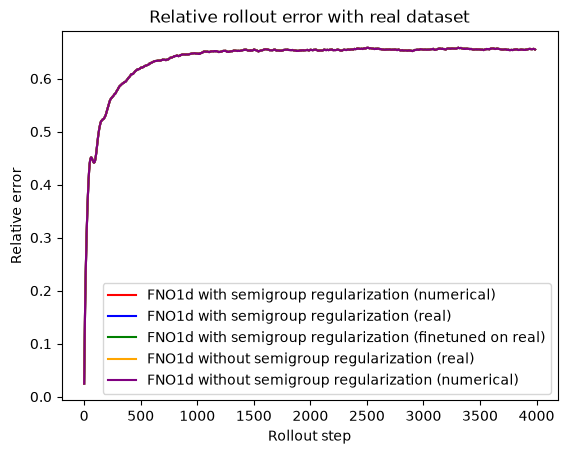

In [10]:
plt.plot(fno1d_numerical_w_sg_rel_error, color="red", label="FNO1d with semigroup regularization (numerical)")
plt.plot(fno1d_real_w_sg_rel_error, color="blue", label="FNO1d with semigroup regularization (real)")
plt.plot(fno1d_finetuned_w_sg_rel_error, color="green", label="FNO1d with semigroup regularization (finetuned on real)")

plt.plot(fno1d_real_wo_sg_rel_error, color="orange", label="FNO1d without semigroup regularization (real)")
plt.plot(fno1d_numerical_wo_sg_rel_error, color="purple", label="FNO1d without semigroup regularization (numerical)")


plt.xlabel("Rollout step")
plt.ylabel("Relative error")
#plt.yscale("log")
plt.title("Relative rollout error with real dataset")
plt.legend()